In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch

In [20]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [21]:
print(df.keys())
df.head()

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [22]:
df.head()
df["gender"] = df["gender"].replace({"male": 1, "female": 0})
df["social_interaction_level"] = df["social_interaction_level"].replace({"low": 0, "medium": 1, "high": 2})
df["platform_usage"] = df["platform_usage"].replace({"Instagram": 0, "TikTok": 1, "Both": 2})

In [23]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,0,7.4,2.9,3.01,1.5,0,2,2,1,0
1,19,0,1.9,1,8.0,2.9,3.22,0.8,2,8,1,10,0
2,17,0,1.3,0,7.6,0.5,3.92,0.0,2,2,4,2,0
3,15,1,7.4,1,6.9,1.6,3.48,0.8,1,1,7,9,0
4,15,0,4.7,2,4.9,3.0,2.37,1.4,1,3,5,2,0


In [41]:
X = df[['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level']]
Y = df["depression_label"]



=== mean +/- std over 10 seeds ===
method               bal_acc            F1           ROC            PR
Raw            0.912±0.051 0.455±0.062 0.981±0.011 0.675±0.136
PCA            0.661±0.110 0.104±0.042 0.748±0.116 0.096±0.052
AE-compress    0.618±0.102 0.083±0.030 0.671±0.108 0.052±0.015
AE-anomaly     0.593±0.082 0.083±0.031 0.635±0.098 0.063±0.021

PR baseline (positive rate) = 0.026
recon MSE last fold | PCA: 0.7512  AE: 0.7218


C:\Users\trist\AppData\Local\Temp\ipykernel_23908\3221176552.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(ti); ax.set_ylim(0,1); ax.set_xticklabels(methods, rotation=20, ha="right")
C:\Users\trist\AppData\Local\Temp\ipykernel_23908\3221176552.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(ti); ax.set_ylim(0,1); ax.set_xticklabels(methods, rotation=20, ha="right")
C:\Users\trist\AppData\Local\Temp\ipykernel_23908\3221176552.py:107: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_title(ti); ax.set_ylim(0,1); ax.set_xticklabels(methods, rotation=20, ha="right")
C:\Users\trist\AppData\Local\Temp\ipykernel_23908\3221176552.py:107: UserWarning: set_ticklabels() should only be used with a fixed numb

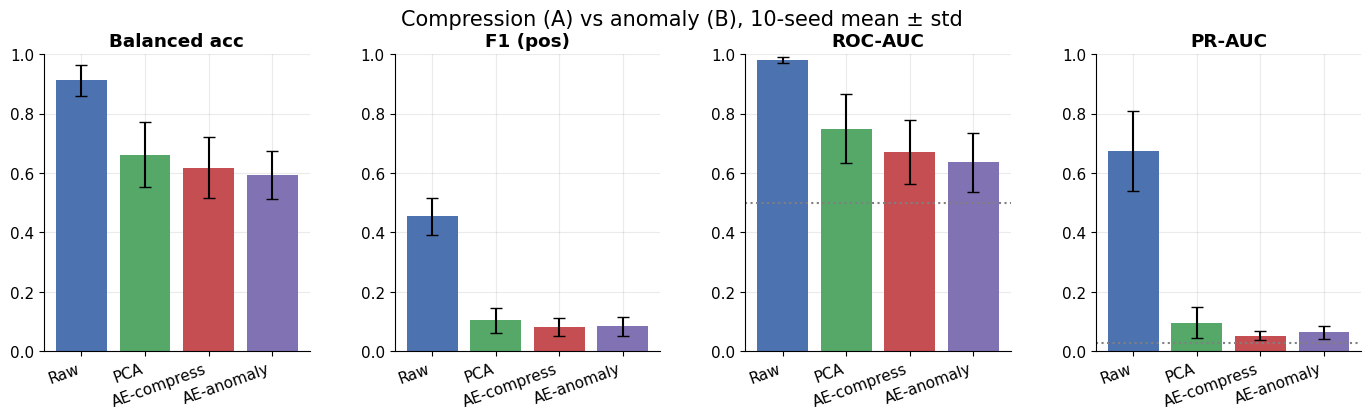

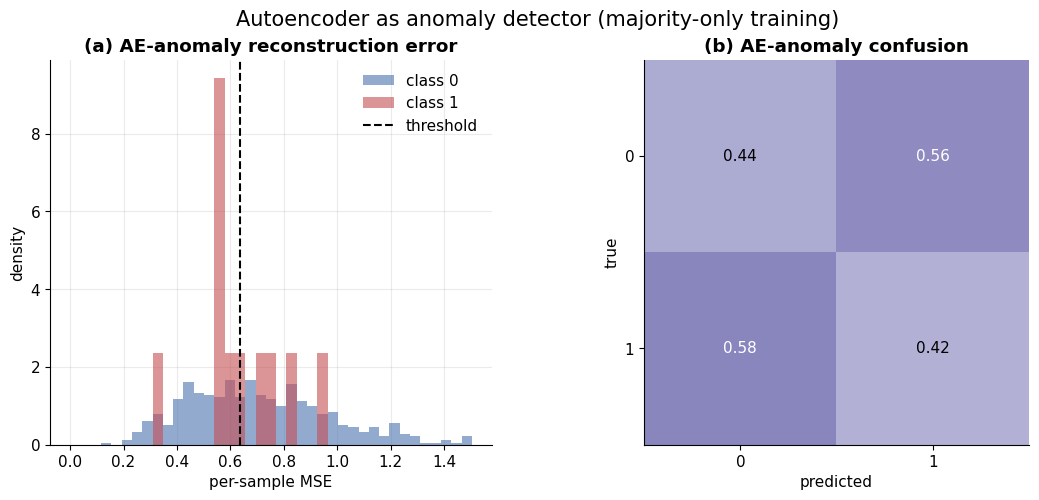

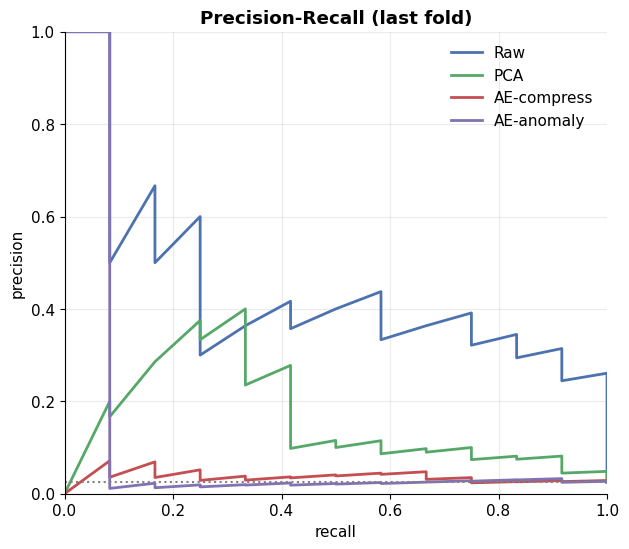

In [68]:
# Assumes X, Y already exist in the session (Y binary, X numeric 2D array/df).
# Both experiments, class_weight='balanced', 10 seeds, mean +/- std. No file saving.

import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (balanced_accuracy_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve)

torch.manual_seed(0); np.random.seed(0)

Xall = np.asarray(X, dtype="float32")
yall = np.asarray(Y).astype(int)
N_SEEDS, K, TEST_SZ = 10, 3, 0.4
base_rate = yall.mean()

class AE(nn.Module):
    def __init__(self, d, k):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, 16), nn.Tanh(), nn.Linear(16, k))
        self.dec = nn.Sequential(nn.Linear(k, 16), nn.Tanh(), nn.Linear(16, d))
    def forward(self, x):
        z = self.enc(x); return self.dec(z), z

def train_ae(Xtr, k, epochs=400, lr=1e-2):
    ae = AE(Xtr.shape[1], k); opt = torch.optim.Adam(ae.parameters(), lr=lr); lf = nn.MSELoss()
    t = torch.tensor(Xtr)
    for _ in range(epochs):
        opt.zero_grad(); out, _ = ae(t); lf(out, t).backward(); opt.step()
    ae.eval(); return ae

def encode(ae, Xa):
    with torch.no_grad(): _, z = ae(torch.tensor(Xa)); return z.numpy()
def recon_err(ae, Xa):
    with torch.no_grad():
        rec, _ = ae(torch.tensor(Xa)); return ((rec - torch.tensor(Xa))**2).mean(1).numpy()

def sup(model, Xte, yte):
    p, s = model.predict(Xte), model.predict_proba(Xte)[:, 1]
    return dict(bal_acc=balanced_accuracy_score(yte, p), f1=f1_score(yte, p),
                roc=roc_auc_score(yte, s), pr=average_precision_score(yte, s),
                pred=p, score=s)

methods = ["Raw", "PCA", "AE-compress", "AE-anomaly"]
agg = {m: {k: [] for k in ["bal_acc", "f1", "roc", "pr"]} for m in methods}
last = {}

for s in range(N_SEEDS):
    Xtr, Xte, ytr, yte = train_test_split(Xall, yall, test_size=TEST_SZ,
                                          random_state=s, stratify=yall)
    sc = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = sc.transform(Xtr).astype("float32"), sc.transform(Xte).astype("float32")

    r = sup(LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr_s, ytr), Xte_s, yte)
    for k in agg["Raw"]: agg["Raw"][k].append(r[k])

    pca = PCA(n_components=K).fit(Xtr_s)
    Ptr, Pte = pca.transform(Xtr_s), pca.transform(Xte_s)
    rp = sup(LogisticRegression(max_iter=2000, class_weight="balanced").fit(Ptr, ytr), Pte, yte)
    for k in agg["PCA"]: agg["PCA"][k].append(rp[k])
    pca_recon = float(np.mean((pca.inverse_transform(Pte) - Xte_s)**2))

    ae_c = train_ae(Xtr_s, K)
    Ztr, Zte = encode(ae_c, Xtr_s), encode(ae_c, Xte_s)
    rae = sup(LogisticRegression(max_iter=2000, class_weight="balanced").fit(Ztr, ytr), Zte, yte)
    for k in agg["AE-compress"]: agg["AE-compress"][k].append(rae[k])
    ae_recon = float(np.mean(recon_err(ae_c, Xte_s)))

    ae_a = train_ae(Xtr_s[ytr == 0], K)          # majority-only
    err_te, err_tr = recon_err(ae_a, Xte_s), recon_err(ae_a, Xtr_s)
    fpr, tpr, thr = roc_curve(ytr, err_tr); cut = thr[np.argmax(tpr - fpr)]
    pa = (err_te >= cut).astype(int)
    agg["AE-anomaly"]["bal_acc"].append(balanced_accuracy_score(yte, pa))
    agg["AE-anomaly"]["f1"].append(f1_score(yte, pa))
    agg["AE-anomaly"]["roc"].append(roc_auc_score(yte, err_te))
    agg["AE-anomaly"]["pr"].append(average_precision_score(yte, err_te))

    if s == N_SEEDS - 1:
        last = dict(yte=yte, raw=r, pca=rp, ae=rae, err=err_te, pa=pa, cut=cut,
                    pca_recon=pca_recon, ae_recon=ae_recon)

print("\n=== mean +/- std over", N_SEEDS, "seeds ===")
print(f"{'method':14s} {'bal_acc':>13s} {'F1':>13s} {'ROC':>13s} {'PR':>13s}")
for m in methods:
    print(f"{m:14s} " + " ".join(f"{np.mean(agg[m][k]):.3f}±{np.std(agg[m][k]):.3f}"
                                 for k in ["bal_acc", "f1", "roc", "pr"]))
print(f"\nPR baseline (positive rate) = {base_rate:.3f}")
print("recon MSE last fold | PCA:", round(last['pca_recon'],4), " AE:", round(last['ae_recon'],4))

# ---- plots ----
plt.rcParams.update({"font.size": 11, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
C = {"Raw":"#4c72b0","PCA":"#55a868","AE-compress":"#c44e52","AE-anomaly":"#8172b3"}

fig1, axes = plt.subplots(1, 4, figsize=(17, 4.5)); fig1.subplots_adjust(wspace=.32, bottom=.22)
for ax, mt, ti in zip(axes, ["bal_acc","f1","roc","pr"],
                      ["Balanced acc","F1 (pos)","ROC-AUC","PR-AUC"]):
    ax.bar(methods, [np.mean(agg[m][mt]) for m in methods],
           yerr=[np.std(agg[m][mt]) for m in methods],
           color=[C[m] for m in methods], capsize=4)
    ax.set_title(ti); ax.set_ylim(0,1); ax.set_xticklabels(methods, rotation=20, ha="right")
    if mt=="pr": ax.axhline(base_rate, ls=":", c="gray")
    if mt=="roc": ax.axhline(.5, ls=":", c="gray")
fig1.suptitle(f"Compression (A) vs anomaly (B), {N_SEEDS}-seed mean ± std", fontsize=15)

fig2, (axh, axc) = plt.subplots(1, 2, figsize=(13, 5)); fig2.subplots_adjust(wspace=.28)
err, yt = last["err"], last["yte"]
bins = np.linspace(0, np.percentile(err, 99), 40)
axh.hist(err[yt==0], bins=bins, density=True, alpha=.6, color="#4c72b0", label="class 0")
axh.hist(err[yt==1], bins=bins, density=True, alpha=.6, color="#c44e52", label="class 1")
axh.axvline(last["cut"], ls="--", c="k", label="threshold")
axh.set(title="(a) AE-anomaly reconstruction error", xlabel="per-sample MSE", ylabel="density")
axh.legend(frameon=False)
cm = confusion_matrix(yt, last["pa"], normalize="true")
axc.imshow(cm, cmap="Purples", vmin=0, vmax=1); axc.grid(False)
axc.set(title="(b) AE-anomaly confusion", xlabel="predicted", ylabel="true",
        xticks=[0,1], yticks=[0,1])
for a in range(2):
    for b in range(2):
        axc.text(b, a, f"{cm[a,b]:.2f}", ha="center", va="center",
                 color="white" if cm[a,b]>.5 else "black")
fig2.suptitle("Autoencoder as anomaly detector (majority-only training)", fontsize=15)

fig3, ax = plt.subplots(figsize=(7, 6))
for nm, rr in [("Raw",last["raw"]),("PCA",last["pca"]),("AE-compress",last["ae"])]:
    pr, rc, _ = precision_recall_curve(last["yte"], rr["score"]); ax.plot(rc, pr, lw=2, color=C[nm], label=nm)
pr, rc, _ = precision_recall_curve(last["yte"], last["err"]); ax.plot(rc, pr, lw=2, color=C["AE-anomaly"], label="AE-anomaly")
ax.axhline(base_rate, ls=":", c="gray")
ax.set(title="Precision-Recall (last fold)", xlabel="recall", ylabel="precision", xlim=(0,1), ylim=(0,1))
ax.legend(frameon=False)
plt.show()